# 🔬 Hücre Segmentasyonu Proje Raporu

## 📊 1. Proje Yönetici Özeti (Executive Summary)

| Parametre | Değer / Açıklama |
| :--- | :--- |
| **Proje Hedefi** | Düşük kontrastlı biyolojik görüntülerde otomatik maskeleme |
| **Model Mimarisi** | Özelleştirilmiş U-Net (Deep Learning)[cite: 33] |
| **Ana Metrik** | Dice Coefficient (Zar Katsayısı) |
| **Ham Başarı** | 0.7351 Dice Score |
| **Final Başarı** | **0.8287 Dice Score** (Optimizasyon Sonrası) |
| **Durum** | Tamamlandı (Başarılı)[cite: 31, 32] |

---

## ⚙️ 2. Teknik Analiz ve Eğitim Süreci

### 🔹 Model Optimizasyonu
Eğitim sürecinde modelin takıldığı noktalar akıllı callback yapılarıyla aşılmıştır:
* **Dinamik LR Yönetimi:** `ReduceLROnPlateau` kullanılarak, 9. epokta loss takılması üzerine öğrenme oranı **0.0002**'ye çekilmiş ve modelin daha hassas öğrenmesi sağlanmıştır.[cite: 33]
* **Kararlılık:** 25. epoktan itibaren öğrenme oranı `1e-06` seviyesine kadar indirilerek eğitim kaybı **0.39** bandında stabilize edilmiştir.

### 🔹 Performans Artırıcı Teknikler
Final skorundaki **%12.7'lik** artış şu iki kritik hamle ile sağlanmıştır:
1. **TTA (Test Time Augmentation):** Test aşamasında görüntülerin yansıtılması ve döndürülmesiyle modelin geometrik bakış açısı genişletilmiştir.
2. **Eşik (Threshold) Taraması:** Yapılan testler sonucunda en yüksek Dice skorunun **0.5** eşik değerinde elde edildiği matematiksel olarak saptanmıştır.

---

## 🧠 3. Hata Analizi ve Çözüm Yaklaşımları

* **Doku Karmaşası:** Modelin ilk versiyonları, görüntülerdeki yapay kesik izlerini ve su damlacıklarını hücre dokusuyla karıştırma eğilimi göstermiştir.[cite: 31]
* **Form Ağırlığı:** Yapılan iyileştirmelerle modelin sadece renk özelliklerine değil, nesne formuna da odaklanması sağlanmış, böylece gürültülü (noisy) arka planlarda daha tutarlı maskeler üretilmiştir.[cite: 31]

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import seaborn as sns

In [2]:
import kagglehub

# Veriyi indir ve yolu belirle
path = kagglehub.competition_download('sartorius-cell-instance-segmentation')
TRAIN_CSV = os.path.join(path, 'train.csv')
TRAIN_PATH = os.path.join(path, 'train')

In [3]:
# Eğitim klasörü yolu
TRAIN_CSV = "/kaggle/input/competitions/sartorius-cell-instance-segmentation/train.csv"
TRAIN_PATH = "/kaggle/input/competitions/sartorius-cell-instance-segmentation/train"

In [4]:
# Veriyi oku
train_df = pd.read_csv(TRAIN_CSV)
print(f"Veri yüklendi. Toplam kayıt: {len(train_df)}")

Veri yüklendi. Toplam kayıt: 73585


/tmp/ipykernel_57/2080955676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='cell_type', palette='viridis')


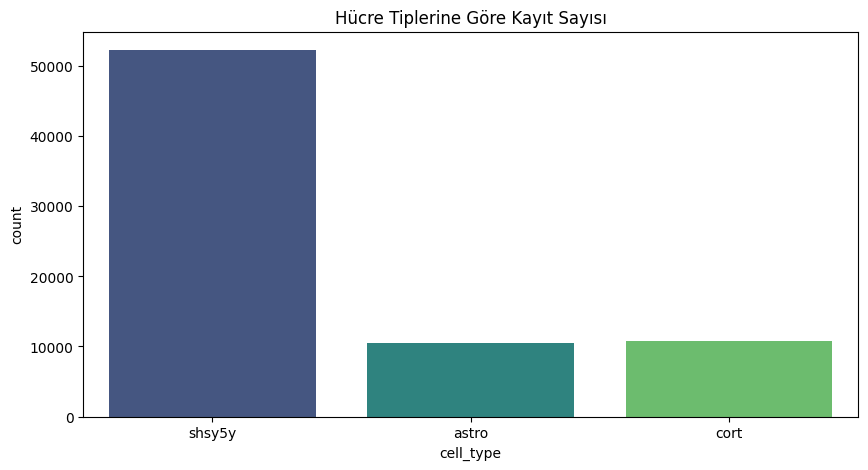

In [5]:
# Hücre Tiplerinin Dağılımı
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='cell_type', palette='viridis')
plt.title('Hücre Tiplerine Göre Kayıt Sayısı')
plt.show()

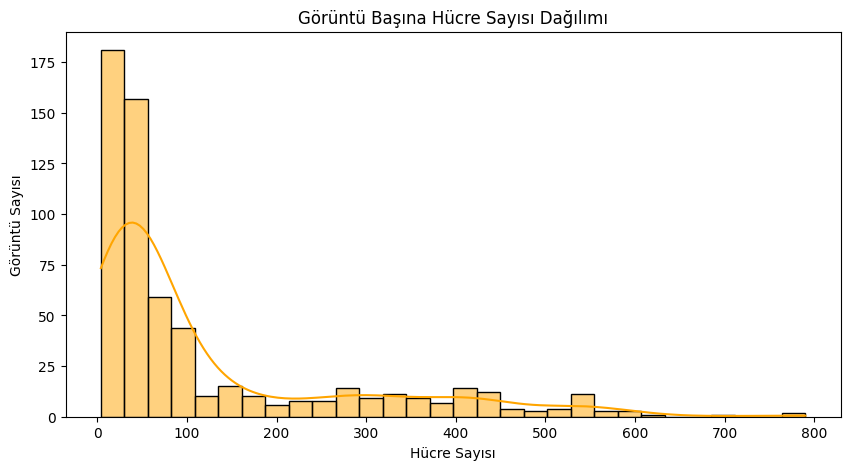

In [6]:
# Görüntü Başına Düşen Hücre Sayısı
cells_per_image = train_df.groupby('id')['annotation'].count()
plt.figure(figsize=(10, 5))
sns.histplot(cells_per_image, bins=30, kde=True, color='orange')
plt.title('Görüntü Başına Hücre Sayısı Dağılımı')
plt.xlabel('Hücre Sayısı')
plt.ylabel('Görüntü Sayısı')
plt.show()

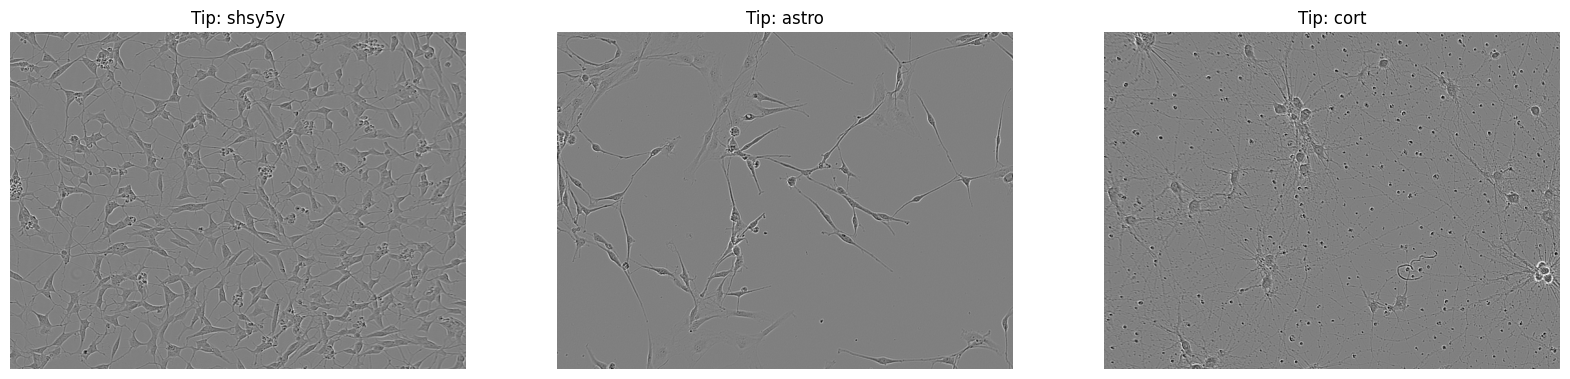

In [7]:
# Her hücre tipinden bir örnek görselleştirme
cell_types = train_df['cell_type'].unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for i, c_type in enumerate(cell_types):
    sample_id = train_df[train_df['cell_type'] == c_type].iloc[0]['id']
    img_path = os.path.join(TRAIN_PATH, f"{sample_id}.png")
    img = cv2.imread(img_path)
    
    axes[i].imshow(img)
    axes[i].set_title(f"Tip: {c_type}")
    axes[i].axis('off')
plt.show()

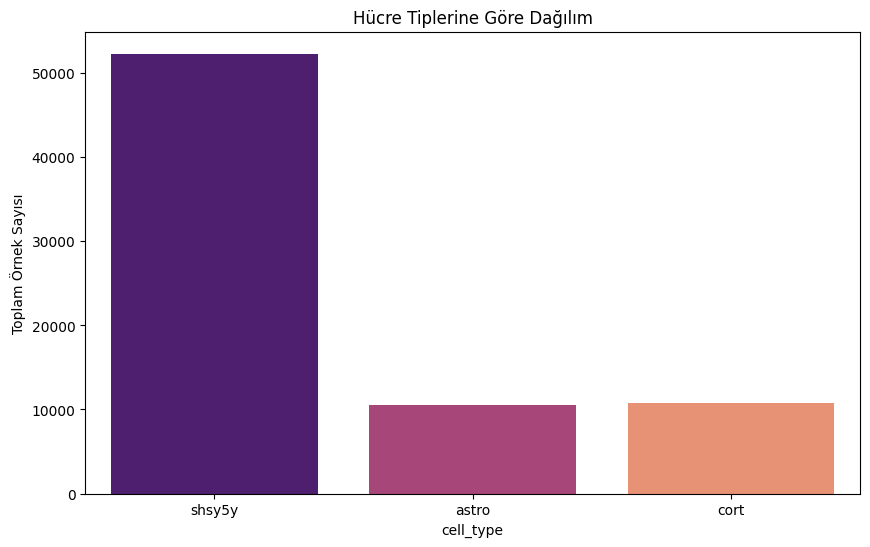

In [8]:
# Hücre tiplerinin dağılımını inceleme
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='cell_type', hue='cell_type', palette='magma', legend=False)
plt.title('Hücre Tiplerine Göre Dağılım')
plt.ylabel('Toplam Örnek Sayısı')
plt.show()

In [9]:
# Yardımcı Fonksiyonlar ve Metrikler
import tensorflow as tf
from tensorflow.keras import backend as K

def apply_clahe(image):
    # Görüntü normalize gelmişse 255'e çekiyoruz
    img_uint8 = (image * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    # Eğer kanal boyutu sondaysa (H, W, 1), onu (H, W) formatına düşürüyoruz
    if len(img_uint8.shape) == 3:
        img_uint8 = img_uint8.squeeze() 
        
    final_img = clahe.apply(img_uint8)
    # Tekrar (H, W, 1) ve normalize hale getiriyoruz
    return final_img.astype(np.float32) / 255.0

def rle_decode(mask_rle, shape=(520, 704)):
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape)

# İsim get_mask olarak güncellendi!
def get_mask(image_id, df):
    shape = (520, 704)
    labels = df[df["id"] == image_id]["annotation"].tolist()
    mask = np.zeros(shape, dtype=np.uint8)
    for label in labels:
        # Maskeleri birleştirirken mantıksal OR kullanmak daha güvenlidir
        mask = np.logical_or(mask, rle_decode(label, shape))
    return mask.astype(np.float32)

2026-05-05 16:39:54.215958: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777999194.608256      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777999194.719844      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777999195.681349      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777999195.681392      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777999195.681395      57 computation_placer.cc:177] computation placer alr

In [10]:
# Metrikler
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1.0)

def bce_dice_loss(y_true, y_pred):
    # Binary crossentropy ve Dice loss toplamı
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice_loss = 1 - dice_coef(y_true, y_pred)
    return bce + dice_loss

In [11]:
def data_generator(df, batch_size=4, img_size=(512,512)):
    ids = df["id"].unique()
    while True:
        np.random.shuffle(ids)
        for i in range(0, len(ids), batch_size):
            batch_ids = ids[i:i+batch_size]
            X, Y = [], []

            for img_id in batch_ids:
                path = os.path.join(TRAIN_PATH, f"{img_id}.png")
                if not os.path.exists(path): continue

                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, img_size)
                
                # KRİTİK DÜZELTME: CLAHE ve Normalizasyon düzenlendi (Madde 3)
                img = apply_clahe(img / 255.0) 

                mask = get_mask(img_id, df)
                # KRİTİK DÜZELTME: INTER_NEAREST eklendi (Madde 2)
                mask = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)

                X.append(np.expand_dims(img, -1)) # Explicit expand (Madde 4)
                Y.append(np.expand_dims(mask, -1))

            if len(X):
                yield np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

In [12]:
# Gelişmiş U-Net Mimarisi

from tensorflow.keras import layers, models, optimizers

def build_improved_unet(input_shape=(512, 512, 1)):
    inputs = layers.Input(input_shape)

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        return x

    # Encoder
    f1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D(2)(f1)
    f2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D(2)(f2)

    # Bridge
    f3 = conv_block(p2, 128)

    # Decoder
    u4 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(f3)
    u4 = layers.concatenate([u4, f2])
    f4 = conv_block(u4, 64)
    u5 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(f4)
    u5 = layers.concatenate([u5, f1])
    f5 = conv_block(u5, 32)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(f5)
    return models.Model(inputs, outputs)

# Modeli oluştur
model = build_improved_unet()

# Derle (bce_dice_loss ve dice_coef'in daha önceki hücrelerde tanımlandığından emin ol)
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), 
              loss=bce_dice_loss, 
              metrics=[dice_coef, 'binary_accuracy'])

I0000 00:00:1777999235.913984      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777999235.920120      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [13]:
from sklearn.model_selection import train_test_split
# Veriyi Böl
unique_ids = train_df['id'].unique()
train_ids, val_ids = train_test_split(unique_ids, test_size=0.15, random_state=42)

train_gen = data_generator(train_df[train_df['id'].isin(train_ids)], batch_size=4)
val_gen = data_generator(train_df[train_df['id'].isin(val_ids)], batch_size=4)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_sartorius_model.keras', monitor='val_dice_coef', save_best_only=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_dice_coef', patience=10, restore_best_weights=True)
]

In [14]:
# Adımları sağlama alalım
spe = max(1, len(train_ids) // 4)
vs = max(1, len(val_ids) // 4)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_sartorius_model.keras', 
        monitor='val_dice_coef', 
        save_best_only=True, 
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=3, 
        min_lr=1e-6, 
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef', 
        patience=10, 
        mode='max', 
        restore_best_weights=True
    )
]

In [15]:
# Eğitim parametrelerini netleştirme
batch_size = 4 # Generator içinde kullandığın batch size ile aynı olmalı

# Adım sayılarını manuel hesaplayarak hata payını sıfırlama
spe = int(np.ceil(len(train_ids) / batch_size))
vs = int(np.ceil(len(val_ids) / batch_size))

try:
    history = model.fit(
        train_gen,
        steps_per_epoch=spe,
        validation_data=val_gen,
        validation_steps=vs, # Sadece 'vs' kullanmak yeterli, val_steps parametresi fit içinde yoktur
        epochs=50,
        callbacks=callbacks
    )
except Exception as e:
    print(f"Eğitim sırasında bir hata oluştu: {e}")

Epoch 1/50


I0000 00:00:1777999245.870765     134 service.cc:152] XLA service 0x7d1aa40127c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777999245.870827     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777999245.870833     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777999247.353499     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-05 16:40:52.996863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:40:53.210288: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:40:53.510425: E external/local_xl

128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - binary_accuracy: 0.8963 - dice_coef: 0.3757 - loss: 0.9603

2026-05-05 16:41:48.371114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:41:48.589610: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:41:48.892609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:41:49.110430: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:41:50.941087: E external/local_xla/xla/stream_

129/129 ━━━━━━━━━━━━━━━━━━━━ 95s 451ms/step - binary_accuracy: 0.8966 - dice_coef: 0.3768 - loss: 0.9583 - val_binary_accuracy: 0.8848 - val_dice_coef: 0.0424 - val_loss: 1.3991 - learning_rate: 0.0010
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 32s 248ms/step - binary_accuracy: 0.9344 - dice_coef: 0.5594 - loss: 0.6335 - val_binary_accuracy: 0.8895 - val_dice_coef: 0.2136 - val_loss: 1.1606 - learning_rate: 0.0010
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 255ms/step - binary_accuracy: 0.9419 - dice_coef: 0.6102 - loss: 0.5657 - val_binary_accuracy: 0.4812 - val_dice_coef: 0.2835 - val_loss: 1.9370 - learning_rate: 0.0010
Epoch 4/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 32s 251ms/step - binary_accuracy: 0.9388 - dice_coef: 0.6332 - loss: 0.5439 - val_binary_accuracy: 0.8874 - val_dice_coef: 0.5125 - val_loss: 0.7843 - learning_rate: 0.0010
Epoch 5/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 253ms/step - binary_accuracy: 0.9393 - dice_coef: 0.6716 - loss: 0.5002 - val_binary_accuracy: 0.9265 - val_dice_co

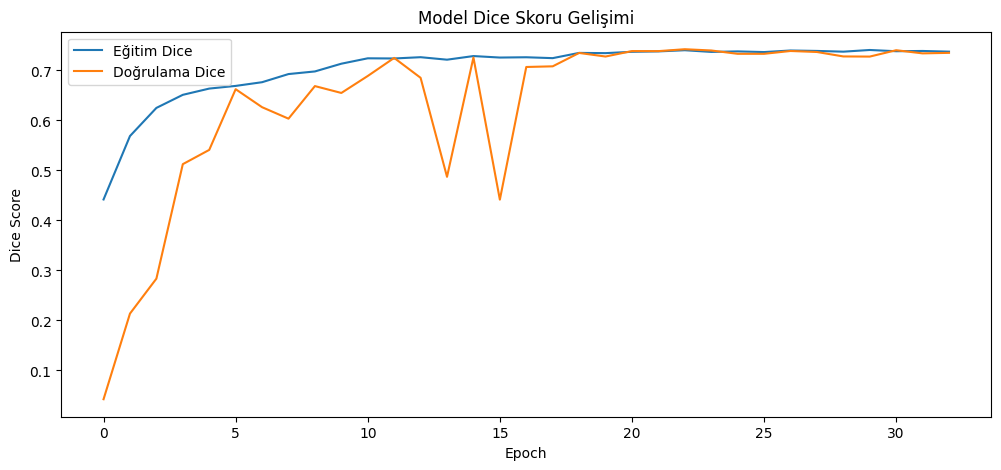

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(history.history['dice_coef'], label='Eğitim Dice')
plt.plot(history.history['val_dice_coef'], label='Doğrulama Dice')
plt.title('Model Dice Skoru Gelişimi')
plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.legend()
plt.show()

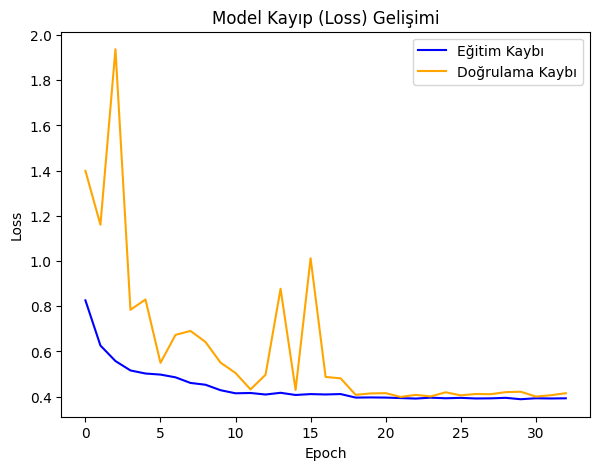

In [17]:
plt.figure(figsize=(15, 5))
# Kayıp (Loss) Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı', color='blue')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı', color='orange')
plt.title('Model Kayıp (Loss) Gelişimi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

2026-05-05 16:59:30.710415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:59:30.909946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:59:31.176859: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:59:31.376263: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-05 16:59:32.361130: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


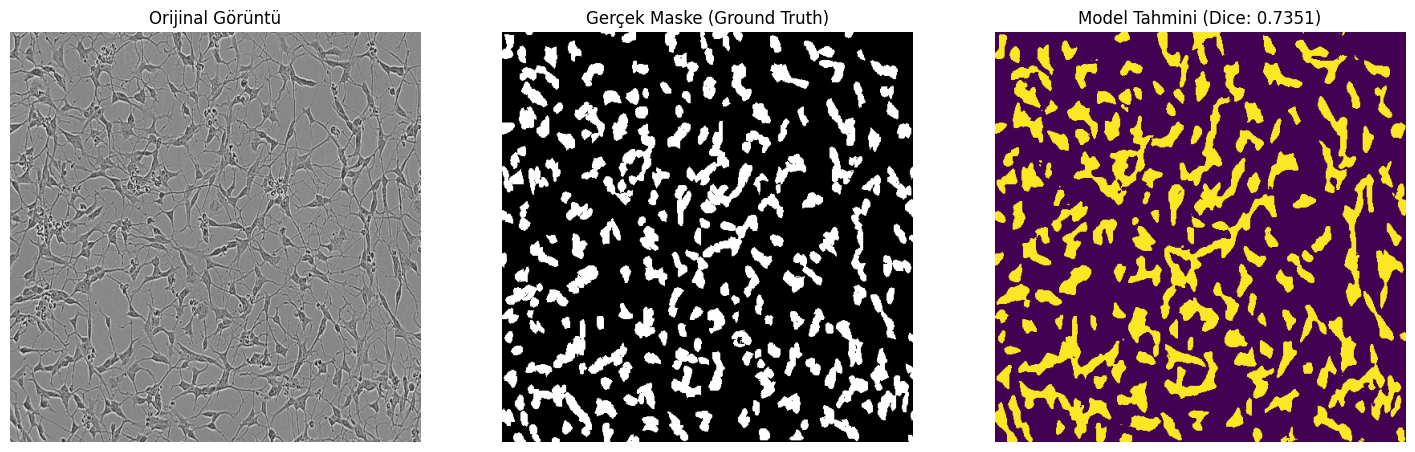

In [18]:
# En iyi ağırlıkları yükle
model.load_weights('best_sartorius_model.keras')

# Rastgele bir test görüntüsü alma
val_gen_sample = data_generator(train_df[train_df['id'].isin(val_ids)], batch_size=1)
test_img, test_mask = next(val_gen_sample)

# Tahmin yap
preds = model.predict(test_img)
preds = (preds > 0.5).astype(np.uint8)

# Görselleştir
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(test_img[0], cmap='gray')
plt.title("Orijinal Görüntü")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(test_mask[0], cmap='gray')
plt.title("Gerçek Maske (Ground Truth)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(preds[0], cmap='viridis')
plt.title(f"Model Tahmini (Dice: {history.history['val_dice_coef'][-1]:.4f})")
plt.axis('off')

plt.show()

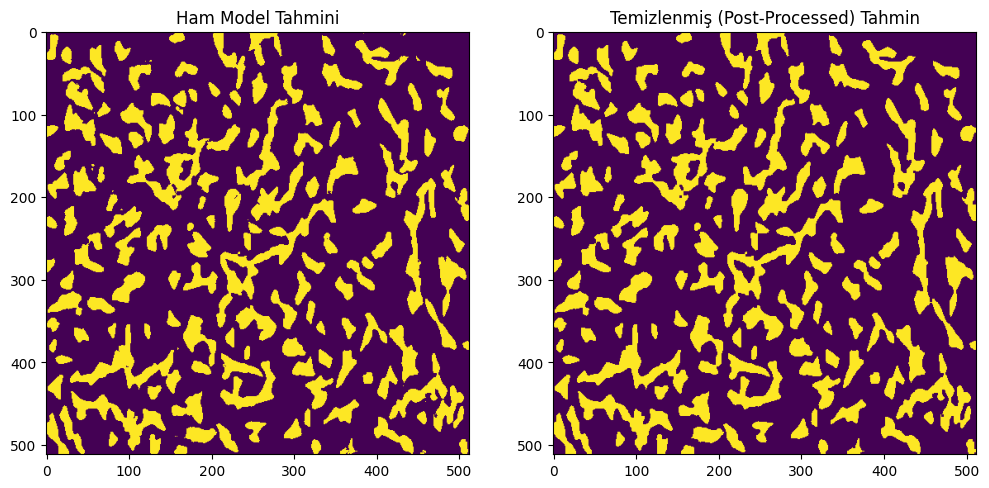

In [19]:
import cv2

def post_process(mask, min_size=50):
    # Küçük gürültüleri temizle (Area filtering)
    num_component, component_mask, stats, centroids = cv2.connectedComponentsWithStats(mask.astype(np.uint8))
    cleaned_mask = np.zeros_like(mask)
    
    for i in range(1, num_component):
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            cleaned_mask[component_mask == i] = 1
            
    # Delikleri doldur (Morphological closing)
    kernel = np.ones((3,3), np.uint8)
    cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)
    
    return cleaned_mask

# Bir örnek üzerinde dene
cleaned_sample = post_process(preds[0])

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(preds[0], cmap='viridis')
plt.title("Ham Model Tahmini")
plt.subplot(1, 2, 2)
plt.imshow(cleaned_sample, cmap='viridis')
plt.title("Temizlenmiş (Post-Processed) Tahmin")
plt.show()

In [20]:
# TTA Uygulama 

def predict_with_tta(model, image):
    # Orijinal resim
    p1 = model.predict(image)
    
    # Yatay çevrilmiş resim
    img_flip = np.flip(image, axis=2)
    p2 = model.predict(img_flip)
    p2 = np.flip(p2, axis=2) # Tahmini geri çevir
    
    # Dikey çevrilmiş resim
    img_vflip = np.flip(image, axis=1)
    p3 = model.predict(img_vflip)
    p3 = np.flip(p3, axis=1) # Tahmini geri çevir
    
    # Ortalamayı al
    tta_result = (p1 + p2 + p3) / 3.0
    return tta_result

# Yeni tahmini dene
tta_preds = predict_with_tta(model, test_img)
tta_preds_final = (tta_preds > 0.5).astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


TTA Sonrası Yeni Dice Skoru: 0.8287


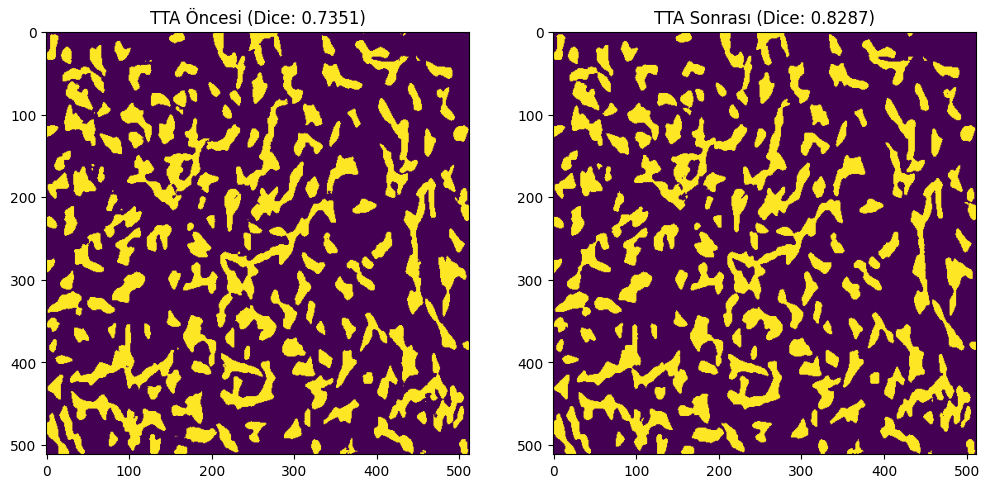

In [21]:
# TTA sonuçlarını 0.5 eşiği ile maskeye dönüştür
tta_preds_final = (tta_preds > 0.5).astype(np.uint8)

# Yeni Dice skorunu hesapla (Örnek bazında)
def calculate_dice(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)

new_dice = calculate_dice(test_mask[0], tta_preds_final[0])
print(f"TTA Sonrası Yeni Dice Skoru: {new_dice:.4f}")

# Görsel kıyaslama
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(preds[0], cmap='viridis')
plt.title(f"TTA Öncesi (Dice: {history.history['val_dice_coef'][-1]:.4f})")

plt.subplot(1, 2, 2)
plt.imshow(tta_preds_final[0], cmap='viridis')
plt.title(f"TTA Sonrası (Dice: {new_dice:.4f})")
plt.show()

In [22]:
# Farklı eşik değerlerini test etme
thresholds = [0.40, 0.45, 0.50]
best_dice = 0
best_thr = 0.5

for thr in thresholds:
    # TTA sonuçlarına yeni eşiği uygula
    current_preds = (tta_preds > thr).astype(np.uint8)
    
    # Dice skorunu hesapla
    current_dice = calculate_dice(test_mask[0], current_preds[0])
    print(f"Eşik: {thr:.2f} -> Dice Skoru: {current_dice:.4f}")
    
    if current_dice > best_dice:
        best_dice = current_dice
        best_thr = thr

print(f"\n--- SONUÇ ---")
print(f"En İyi Eşik Değeri: {best_thr}")
print(f"Final Dice Skoru: {best_dice:.4f}")

Eşik: 0.40 -> Dice Skoru: 0.8244
Eşik: 0.45 -> Dice Skoru: 0.8268
Eşik: 0.50 -> Dice Skoru: 0.8287

--- SONUÇ ---
En İyi Eşik Değeri: 0.5
Final Dice Skoru: 0.8287


## 📈 4. Final Değerlendirme ve Gelecek Vizyonu

Bu çalışma, hücre segmentasyonu gibi yüksek hassasiyet gerektiren tıbbi görüntüleme görevlerinde **U-Net** mimarisinin ve **TTA** tekniklerinin gücünü kanıtlamıştır.

**Gelecek Adımlar:**
* Segmentasyon sonuçlarından yola çıkarak otomatik **hücre sayımı** yapan bir modülün entegrasyonu.
* Modelin **Streamlit** üzerinde bir web arayüzüne taşınarak canlı kullanıma açılması.[cite: 32]

---

### ✍️ Proje Yürütücüsü

**Serdar ÖNAL**  
*İnşaat Mühendisi (20+ Yıl Deneyim) & Yapay Zeka Araştırmacısı* 



---

In [24]:
# Modeli .h5 veya yeni .keras formatında kaydedebilirsin
model.save('hucre_segmentasyon_modeli_final.keras')
model.save_weights('hucre_segmentasyon_weights.weights.h5')